# 서비스 기획 3W - 카페 매장 지역별 맞춤 전략 분석
#### 1. Why
- 뉴욕 3개 카페 매장(Lower Manhattan, Hell's Kitchen, Astoria)이 동일한 메뉴/가격 정책으로 운영되고 있는데,
  지역별 상권 특성(오피스가 vs 주거지역 등)에 따라 실제 소비 패턴은 다를 수 있음
- 데이터 분석을 통해 지역별 차이를 검증하고, 매장별 맞춤 운영 전략이 필요한지 판단
#### 2. Who
- 3개 매장을 총괄하는 카페 체인 운영 매니저 / 지점 점장
#### 3. What
- 지역별 매출 패턴(카테고리 구성, 시간대, 객단가)을 비교 분석하여
  획일적 운영이 아닌 **지역 맞춤형 운영 전략(메뉴 구성, 영업시간, 인력배치)**을 도출


### 데이터 불러오기

In [1]:
# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 한글 폰트 설정 (Noto Sans CJK KR)
plt.rcParams['font.family'] = 'Noto Sans CJK KR'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')


In [3]:
data = pd.read_excel('./data/Coffee Shop Sales.xlsx', sheet_name='Transactions')

data

,거래번호,거래날짜,거래시간,거래수량,카페일련번호,카페지역,상품번호,제품가격,카테고리,제품명,제품설명
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
...,...,...,...,...,...,...,...,...,...,...,...
149111,149452,2023-06-30,20:18:41,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg
149112,149453,2023-06-30,20:25:10,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg
149113,149454,2023-06-30,20:31:34,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg
149114,149455,2023-06-30,20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino


In [4]:
# 데이터 기본 정보 확인
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   거래번호    149116 non-null  int64         
 1   거래날짜    149116 non-null  datetime64[ns]
 2   거래시간    149116 non-null  object        
 3   거래수량    149116 non-null  int64         
 4   카페일련번호  149116 non-null  int64         
 5   카페지역    149116 non-null  object        
 6   상품번호    149116 non-null  int64         
 7   제품가격    149116 non-null  float64       
 8   카테고리    149116 non-null  object        
 9   제품명     149116 non-null  object        
 10  제품설명    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


In [5]:
# 결측치 확인
data.isnull().sum()

거래번호      0
거래날짜      0
거래시간      0
거래수량      0
카페일련번호    0
카페지역      0
상품번호      0
제품가격      0
카테고리      0
제품명       0
제품설명      0
dtype: int64

In [6]:
# 거래번호를 인덱스로 설정
data.set_index('거래번호', inplace=True)

data.head()

,거래날짜,거래시간,거래수량,카페일련번호,카페지역,상품번호,제품가격,카테고리,제품명,제품설명
거래번호,,,,,,,,,,
1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


### [결측치 및 이상치 처리]
- 결측치는 확인 결과 존재하지 않음
- 제품가격(연속형 변수)에 대해서만 이상치 여부 확인

In [32]:
#결측치 확인
data.isnull().sum()

거래날짜      0
거래시간      0
거래수량      0
카페일련번호    0
카페지역      0
상품번호      0
제품가격      0
카테고리      0
제품명       0
제품설명      0
매출        0
시간대       0
요일        0
평일주말      0
dtype: int64

In [28]:
# 제품가격 이상치 확인 (IQR 방식)
Q1 = data['제품가격'].quantile(0.25)
Q3 = data['제품가격'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_cnt = len(data.loc[(data['제품가격'] < lower) | (data['제품가격'] > upper)])
print('$5.625 넘어가면 이상치')
print(f'이상치 개수: {outlier_cnt}건 / 전체 {len(data)}건')
# -> 프리미엄 원두, 브랜드 상품 등 고가 상품이 정상적으로 존재하는 것이므로
#    수치상 이상치이지만 실제 데이터 오류는 아님. 별도 제거하지 않고 그대로 사용
#    $ 5.625 넘어가면 이상치

$5.625 넘어가면 이상치
이상치 개수: 4212건 / 전체 149116건


### 데이터 연산 (파생변수 생성)
- 분석에 필요한 매출, 시간대, 요일, 평일/주말 컬럼을 새로 생성

In [8]:
# 매출 = 거래수량 * 제품가격
data['매출'] = data['거래수량'] * data['제품가격']

# 거래시간에서 시간대(hour)만 추출
data['시간대'] = pd.to_datetime(data['거래시간'], format='%H:%M:%S').dt.hour

# 거래날짜에서 요일 추출
data['요일'] = data['거래날짜'].dt.day_name()

# 평일/주말 구분
data['평일주말'] = data['요일'].isin(['Saturday', 'Sunday']).map({True: '주말', False: '평일'})

data[['거래날짜', '거래시간', '시간대', '요일', '평일주말', '거래수량', '제품가격', '매출']].head()

,거래날짜,거래시간,시간대,요일,평일주말,거래수량,제품가격,매출
거래번호,,,,,,,,
1,2023-01-01,07:06:11,7,Sunday,주말,2,3.0,6.0
2,2023-01-01,07:08:56,7,Sunday,주말,2,3.1,6.2
3,2023-01-01,07:14:04,7,Sunday,주말,2,4.5,9.0
4,2023-01-01,07:20:24,7,Sunday,주말,1,2.0,2.0
5,2023-01-01,07:22:41,7,Sunday,주말,2,3.1,6.2


# 1. 시나리오 (문제 배경 및 분석 목적)
> 카페 체인은 Lower Manhattan, Hell's Kitchen, Astoria 3개 지역에서 매장을 운영 중이며,
> 현재는 **모든 매장이 동일한 메뉴 구성, 가격 정책, 영업시간**으로 운영되고 있다.
>
> 하지만 세 지역은 상권 성격이 다르다. Lower Manhattan은 대표적인 **오피스 밀집 지역**이고,
> Astoria는 **주거 밀집 지역**에 가깝다. 상권이 다르면 고객의 방문 시간대, 선호 메뉴,
> 소비 금액도 다를 가능성이 높다.
>
> 이에 따라 매장(지역)별 실제 판매 데이터를 분석하여 **지역별 소비 패턴 차이를 검증**하고,
> 차이가 확인되는 영역에 한해 **지역 맞춤형 운영 전략(메뉴 구성, 영업시간, 인력배치)**을 제시하고자 한다.

# 2. 가설설정
> 1. 지역마다 잘 팔리는 상품 카테고리 구성비가 다를 것이다.
> 2. 지역마다 고객이 몰리는 시간대(피크타임) 패턴이 다를 것이다.
> 3. 지역마다 객단가(거래당 평균 구매금액)에 차이가 있을 것이다.


# 3. 가설검증

## 1) 지역마다 잘 팔리는 상품 카테고리 구성비가 다를 것이다.

In [9]:
# 지역, 카테고리 기준 매출 합계
# groupby로 지역-카테고리별 매출을 구한 뒤, pivot 형태로 변환
region_cat = data.groupby(['카페지역', '카테고리'])['매출'].sum().unstack()

# 지역 내 카테고리 비중(%)으로 정규화 -> 지역별 매출 규모 차이를 제거하고 '구성비'만 비교
region_cat_pct = region_cat.div(region_cat.sum(axis=1), axis=0) * 100
region_cat_pct.round(1)

카테고리,Bakery,Branded,Coffee,Coffee beans,Drinking Chocolate,Flavours,Loose Tea,Packaged Chocolate,Tea
카페지역,,,,,,,,,
Astoria,11.5,2.3,38.6,4.4,11.3,0.8,1.4,0.5,29.2
Hell's Kitchen,11.6,0.8,38.6,7.9,10.0,1.2,1.9,0.7,27.4
Lower Manhattan,12.3,2.7,38.7,4.9,9.8,1.6,1.5,0.7,27.8


In [21]:
# 1. 폰트 설정 (Windows 기준 'Malgun Gothic', Mac 기준 'AppleGothic')
plt.rc('font', family='Malgun Gothic')

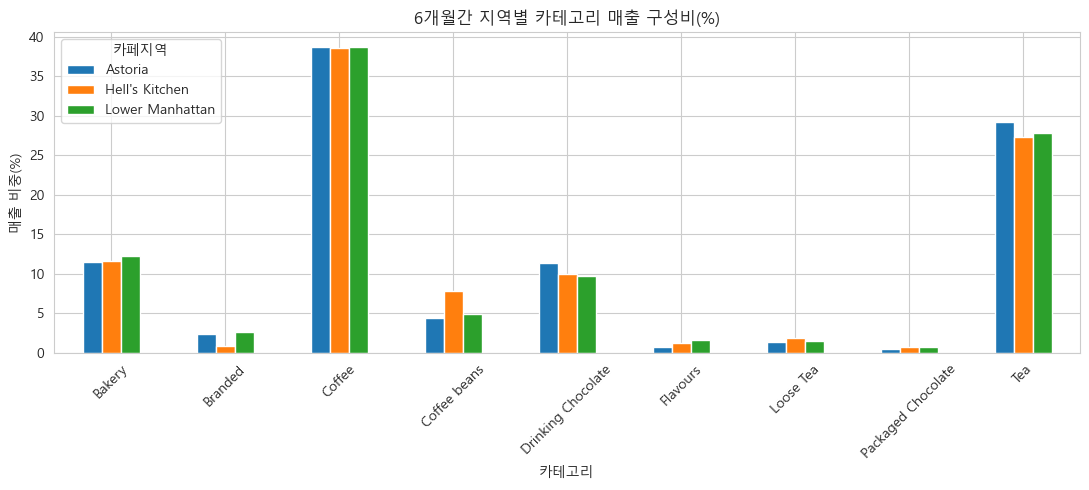

In [42]:
# 지역별 카테고리 구성비 시각화
region_cat_pct.T.plot(kind='bar', figsize=(11, 5))
plt.title('6개월간 지역별 카테고리 매출 구성비(%)')
plt.ylabel('매출 비중(%)')
plt.xlabel('카테고리')
plt.xticks(rotation=45)
plt.legend(title='카페지역')
plt.tight_layout()
plt.show()

## 카테고리 구성비 분석 결과
> ### 분석 결과
> - Coffee(약 38~39%), Tea(약 27~29%) 비중이 세 지역 모두 거의 동일하게 1, 2위를 차지
> - Bakery, Drinking Chocolate 등 나머지 카테고리 비중도 지역 간 차이가 1~2%p 수준에 불과
> - **가설 1은 기각** : 상품 카테고리 구성비는 지역과 무관하게 매우 유사함 → 메뉴 포트폴리오 자체는 지역별로 다르게 가져갈 필요가 없어 보임


## 2) 지역마다 고객이 몰리는 시간대(피크타임) 패턴이 다를 것이다.

In [11]:
# 지역별 영업시간 범위 확인
data.groupby('카페지역')['시간대'].agg(['min', 'max'])

,min,max
카페지역,,
Astoria,7,19
Hell's Kitchen,6,20
Lower Manhattan,6,20


In [12]:
# 지역, 시간대 기준 매출 합계 후 지역 내 비중(%)으로 정규화
region_time = data.groupby(['카페지역', '시간대'])['매출'].sum().unstack()
region_time_pct = region_time.div(region_time.sum(axis=1), axis=0) * 100
region_time_pct.T.round(1)

카페지역,Astoria,Hell's Kitchen,Lower Manhattan
시간대,,,
6,NaN,3.2,6.2
7,8.2,6.7,12.4
8,9.8,13.3,12.3
9,10.0,13.9,12.7
10,10.5,14.2,13.3
11,6.7,7.6,5.6
12,6.8,4.8,5.7
13,6.9,5.1,5.4
14,6.5,5.2,6.0


In [54]:
data['카테고리'].value_counts()

카테고리
Coffee                58416
Tea                   45449
Bakery                22796
Drinking Chocolate    11468
Flavours               6790
Coffee beans           1753
Loose Tea              1210
Branded                 747
Packaged Chocolate      487
Name: count, dtype: int64

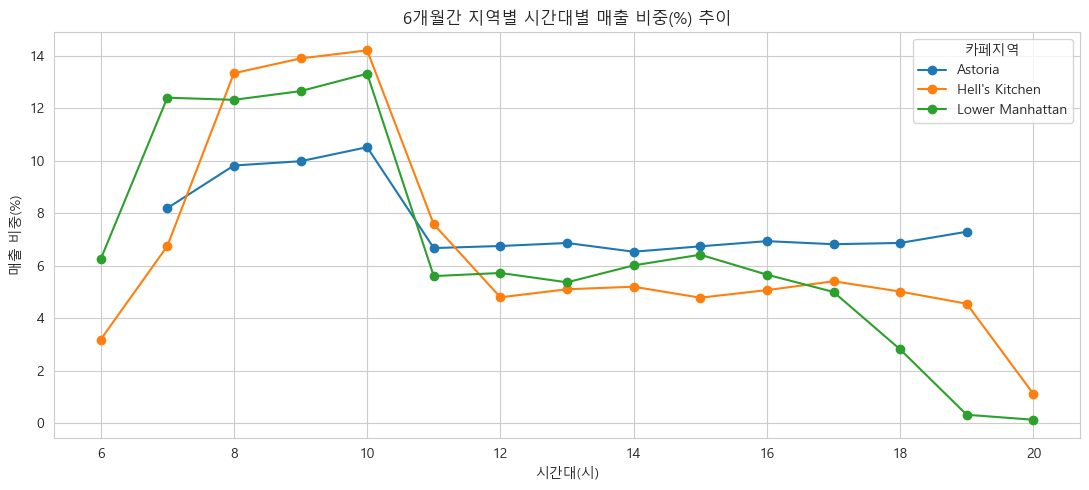

In [33]:
# 지역별 시간대 매출 비중 추이 시각화 (lineplot)
plt.figure(figsize=(11, 5))
for region in region_time_pct.index:
    plt.plot(region_time_pct.columns, region_time_pct.loc[region], marker='o', label=region)

plt.title('6개월간 지역별 시간대별 매출 비중(%) 추이')
plt.xlabel('시간대(시)')
plt.ylabel('매출 비중(%)')
plt.legend(title='카페지역')
plt.tight_layout()
plt.show()

## 피크타임 분석 결과
> ### 분석 결과
> - 세 지역 모두 오전 8~10시가 매출 최고 시간대라는 점은 동일 (출근길 커피 수요는 공통적)
> - 하지만 **저녁 시간대 패턴은 뚜렷하게 다름**
>   - Lower Manhattan: 18시 이후 매출 비중이 2.8% → 19시 0.3% → 20시 0.1%로 급격히 감소, 사실상 저녁 영업이 의미가 없음
>   - Astoria: 18시 6.9%, 19시 7.3%로 오전 피크타임과 큰 차이 없이 저녁까지 꾸준히 매출 발생, 영업시간도 7~19시로 더 늦게 열고 늦게 닫음
>   - Hell's Kitchen: 두 지역의 중간 정도의 완만한 감소 패턴
> - **가설 2는 채택** : Lower Manhattan은 전형적인 '오피스 상권형(출퇴근 집중)', Astoria는 '주거 상권형(하루 종일 분산)' 패턴을 보임


## 3) 지역마다 객단가(거래당 평균 구매금액)에 차이가 있을 것이다.

In [14]:
# 거래(주문) 단위로 매출 합산 -> 객단가 계산
# 원본 data는 한 거래번호(인덱스) 안에 여러 상품 행이 섞여있을 수 있으므로 reset_index 후 재집계
trans = data.reset_index().groupby(['거래번호', '카페지역'])['매출'].sum().reset_index()

trans.groupby('카페지역')['매출'].agg(['mean', 'median', 'std']).round(2)

,mean,median,std
카페지역,,,
Astoria,4.59,3.75,2.88
Hell's Kitchen,4.66,3.75,5.84
Lower Manhattan,4.81,3.75,3.28


### O의 의미
- 이 데이터에서는 거래당 매출이 보통 $10 안쪽인데, $12~18 사이에 찍힌 동그라미들은 한 번에 원두나 브랜드 상품처럼 비싼 걸 여러 개 같이 산 거래이다.
- 개수가 적어서(전체 15만 건 중 극소수) 점으로 하나씩 표시된 거고, 세 지역 모두 비슷한 위치에 비슷한 개수로 찍혀 있는 것도 "이 이상치 패턴조차 지역별로 다르지 않다"는 걸 보여줌

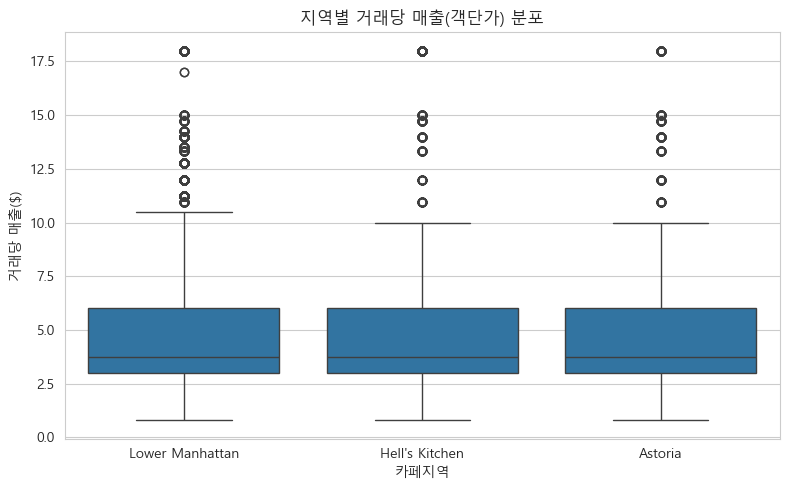

In [24]:
# 지역별 객단가 분포 시각화 (boxplot, 극단값 영향 줄이기 위해 상위 1% 제외하고 시각화)
upper_bound = trans['매출'].quantile(0.99)
trans_vis = trans[trans['매출'] <= upper_bound]

plt.figure(figsize=(8, 5))
sns.boxplot(data=trans_vis, x='카페지역', y='매출')
plt.title('지역별 거래당 매출(객단가) 분포')
plt.ylabel('거래당 매출($)')
plt.tight_layout()
plt.show()

## 객단가 분석 결과
> ### 분석 결과
> - 평균 객단가는 Lower Manhattan(약 $4.81) > Hell's Kitchen(약 $4.66) > Astoria(약 $4.59) 순
> - 다만 그 차이는 약 5% 내외로 크지 않고, 분포(boxplot)도 세 지역이 거의 겹침
> - **가설 3은 기각에 가까움** : 통계적으로 유의미하다고 보기엔 차이가 작아, 객단가 자체를 지역별 전략의 핵심 축으로 삼기는 어려움


## 분석결과 종합
#### 카테고리 구성비
> - Coffee, Tea 중심의 판매 구조는 세 지역 모두 동일 → 메뉴 포트폴리오는 공통 유지가 합리적

#### 시간대(피크타임) 패턴
> - 오전 피크(8~10시)는 공통이나, 저녁 시간대 이용 패턴은 지역별로 확연히 다름
> - Lower Manhattan = 오피스 상권형(출퇴근 집중, 저녁 영업 의미 낮음)
> - Astoria = 주거 상권형(저녁까지 꾸준한 수요)
> - Hell's Kitchen = 중간 성격의 혼합 상권

#### 객단가
> - 지역 간 차이는 존재하나(Lower Manhattan이 근소하게 높음) 폭이 작아 유의미한 전략 포인트로 보기는 어려움


## 인사이트 도출
#### 메뉴는 공통, 운영시간·인력은 지역 맞춤이 정답
>- 카테고리/상품 구성은 지역과 무관하게 이미 최적화되어 있어 메뉴 다양화보다 '운영 시간과 인력 배치' 쪽에 개선 여지가 큼

#### Lower Manhattan: 출퇴근 집중형 매장
>- 8~10시 오전 피크에 인력을 집중 배치하고, 19~20시는 영업시간 단축 또는 인력 최소화로 비용 절감 가능

#### Astoria: 종일 분산형 매장
>- 오전뿐 아니라 저녁까지 고르게 인력을 배치해야 하며, 저녁 시간대 프로모션(예: 애프터눈/이브닝 세트)의 효과가 상대적으로 클 것으로 기대

#### Hell's Kitchen: 혼합형 매장
>- 두 패턴의 중간 성격을 가지므로, 두 전략을 절충한 완만한 인력 배치가 적합


## 페르소나
- 우리 서비스(분석 결과 기반 매장 운영 대시보드)를 사용할 핵심 사용자

### 1. 기본 정보
- **이름**: 김운영
- **나이**: 34
- **성별**: 여

### 2. 배경 및 상황
- **직무**: 카페 체인 3개 지점을 총괄하는 지역 운영 매니저
- **현재 상태**: 본사 지침에 따라 3개 매장을 동일한 방식으로 운영 중이나, 매장별 매출/인건비 효율 차이를 체감하고 있음

### 3. 문제 인식 및 고민
- **현재 느끼는 고민**: "왜 같은 메뉴, 같은 시스템인데 매장마다 저녁 매출 편차가 큰지 감으로만 파악하고 있다"
- **기존에 겪은 불만족스러운 경험**: 저녁 시간대에 Lower Manhattan 매장에 정직원을 그대로 배치해 인건비 대비 매출 효율이 떨어졌던 경험

### 4. 동기와 목표
- 감이 아니라 데이터에 근거해서 매장별 영업시간·인력 배치를 조정하고 싶음


## 솔루션 도출 – RegionFit

### 🎯 목표
지역(상권) 특성에 따라 매장별 운영 전략(영업시간, 인력배치, 프로모션 타이밍)을
데이터 기반으로 자동 제안하는 솔루션

### 📌 솔루션명
**RegionFit** — 상권 유형 진단 기반 매장 운영 최적화 대시보드

### 🔧 주요 기능 구성

| 기능 구분 | 기능 설명 | 기대 효과 |
|-----------|-----------|------------|
| **1. 상권 유형 자동 분류** | 시간대별 매출 분포를 기준으로 매장을 '오피스형/주거형/혼합형'으로 자동 분류 | 신규 매장도 데이터만 쌓이면 빠르게 상권 유형 파악 |
| **2. 시간대별 인력배치 추천** | 상권 유형별 피크타임에 맞춰 시간대별 권장 인력 수 제안 | 인건비 대비 매출 효율 개선 |
| **3. 저녁 프로모션 타겟팅** | 주거형 매장에 한해 저녁 시간대 프로모션 효과 시뮬레이션 제공 | 상권 특성에 안 맞는 프로모션 비용 낭비 방지 |
| **4. 매장 간 비교 리포트** | 카테고리 구성비/객단가는 공통 지표로, 시간대 패턴은 차별 지표로 시각화 | 본사-지점 간 공통 논의 기반 마련 |
